# Прогнозирование зарплаты по описанию вакансии

In [ ]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.5f}".format)

TARGET = "salary_mean_net"
ID_COL = "id"
RANDOM_STATE = 42
VALIDATION_SIZE = 0.2


def find_project_dir() -> Path:
    current_dir = Path.cwd().resolve()
    candidates = [
        current_dir,
        current_dir.parent,
        current_dir / "3_vacancies",
        current_dir.parent / "3_vacancies",
    ]
    candidates.extend(current_dir.parents)
    candidates.extend(parent / "3_vacancies" for parent in current_dir.parents)

    seen = set()
    for candidate in candidates:
        try:
            path = candidate.resolve()
        except OSError:
            continue
        if path in seen:
            continue
        seen.add(path)
        if (path / "data" / "train.csv").exists() and (path / "data" / "test_x.csv").exists():
            return path

    raise FileNotFoundError("Не найдена папка проекта с data/train.csv")


BASE_DIR = find_project_dir()
DATA_DIR = BASE_DIR / "data"
SUBMISSIONS_DIR = BASE_DIR / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test_x.csv"

SUBMISSION_00_PATH = SUBMISSIONS_DIR / "submission_00_dummy_median.csv"
SUBMISSION_01_PATH = SUBMISSIONS_DIR / "submission_01_categorical_ridge.csv"
SUBMISSION_02_PATH = SUBMISSIONS_DIR / "submission_02_compact_tfidf.csv"
FINAL_SUBMISSION_PATH = SUBMISSIONS_DIR / "submission_03_description_tfidf.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

y_train = train[TARGET].astype(float).clip(lower=1.0)

print(BASE_DIR)
print(train.shape, test.shape)

## 1. Оценка качества моделей

Метрика: MAPE. 
Для сопоставления этапов используется одна и та же validation-выборка из 20% train. После выбора конфигурации модель обучается на всей обучающей выборке и формирует файл для отправки.

In [2]:
def clipped_mape(y_true, y_pred) -> float:
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1.0, None)
    return mean_absolute_percentage_error(y_true, y_pred)


evaluation_artifacts = {}


def evaluate_model(name: str, model, X: pd.DataFrame, y: pd.Series) -> tuple[object, dict]:
    start = time.perf_counter()
    validation_model = clone(model)
    validation_model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
    valid_pred = validation_model.predict(X.iloc[valid_idx])

    fitted = clone(model)
    fitted.fit(X, y)
    train_pred = fitted.predict(X)

    elapsed = time.perf_counter() - start
    valid_y = y.iloc[valid_idx].copy()
    valid_pred = np.clip(np.asarray(valid_pred, dtype=float), 1.0, None)
    evaluation_artifacts[name] = {
        "valid_y": valid_y,
        "valid_pred": valid_pred,
        "valid_residuals": valid_y.values - valid_pred,
    }
    return fitted, {
        "model_step": name,
        "input_columns": X.shape[1],
        "train_mape": clipped_mape(y, train_pred),
        "valid_mape": clipped_mape(y.iloc[valid_idx], valid_pred),
        "valid_mape_pct": clipped_mape(y.iloc[valid_idx], valid_pred) * 100,
        "fit_eval_seconds": elapsed,
    }


def save_submission(model, X_test: pd.DataFrame, path: Path) -> pd.DataFrame:
    preds = model.predict(X_test)
    preds = np.clip(preds, 1.0, None)
    submission = pd.DataFrame({ID_COL: test[ID_COL].values, TARGET: preds})
    submission.to_csv(path, index=False)
    return submission

## 2. Подготовка признаков

Общая функция очистки используется на всех этапах. 

In [3]:
TEXT_COLUMNS = [
    "name",
    "employer_name",
    "key_skills_name",
    "raw_description",
    "raw_branded_description",
    "lemmaized_wo_stopwords_raw_description",
    "lemmaized_wo_stopwords_raw_branded_description",
    "name_clean",
    "employer_industries",
]

CATEGORICAL_COLUMNS = [
    "accept_handicapped",
    "accept_kids",
    "if_foreign_language",
    "is_branded_description",
    "experience_name",
    "schedule_name",
    "employment_name",
    "professional_roles_name",
    "specializations_profarea_name",
    "unified_address_region",
    "unified_address_state",
    "unified_address_city",
    "unified_address_country",
    "employer_industries",
]

NUMERIC_META_COLUMNS = [
    "raw_description_words",
    "raw_description_chars",
    "name_words",
    "skills_count",
    "has_city",
    "has_employer_id",
    "has_raw_branded_description",
]


def count_skills(series: pd.Series) -> pd.Series:
    normalized = series.fillna("").astype(str).str.strip().str.lower()
    counts = normalized.str.split(",").map(lambda items: sum(bool(item.strip()) for item in items))
    return counts.mask(normalized.isin(["", "[]", "не указано"]), 0).astype(float)


def prepare_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for column in TEXT_COLUMNS + CATEGORICAL_COLUMNS:
        if column not in out.columns:
            out[column] = np.nan

    for column in TEXT_COLUMNS:
        out[column] = out[column].fillna("").astype(str)

    for column in CATEGORICAL_COLUMNS:
        out[column] = out[column].fillna("unknown").astype(str)

    out["raw_description_words"] = out["raw_description"].str.split().str.len().astype(float)
    out["raw_description_chars"] = out["raw_description"].str.len().astype(float)
    out["name_words"] = out["name"].str.split().str.len().astype(float)
    out["skills_count"] = count_skills(out["key_skills_name"])
    out["has_city"] = df["unified_address_city"].notna().astype(float)
    out["has_employer_id"] = df["employer_id"].notna().astype(float) if "employer_id" in df else 0.0
    out["has_raw_branded_description"] = df["raw_branded_description"].notna().astype(float)

    if "employer_id" in out.columns:
        employer_id = out["employer_id"].fillna(-1).astype(str)
        out["employer_id_token"] = "employer_" + employer_id
    else:
        out["employer_id_token"] = "employer_unknown"

    return out.replace([np.inf, -np.inf], np.nan)


X_train = prepare_frame(train.drop(columns=[TARGET], errors="ignore"))
X_test = prepare_frame(test)

target_bins = pd.qcut(y_train, q=10, duplicates="drop")
fit_idx, valid_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=target_bins,
)

display(X_train[CATEGORICAL_COLUMNS + NUMERIC_META_COLUMNS].head())

,accept_handicapped,accept_kids,if_foreign_language,is_branded_description,experience_name,schedule_name,employment_name,professional_roles_name,specializations_profarea_name,unified_address_region,unified_address_state,unified_address_city,unified_address_country,employer_industries,raw_description_words,raw_description_chars,name_words,skills_count,has_city,has_employer_id,has_raw_branded_description
0,True,False,Не указано,заполнено,Нет опыта,Полный день,Полная занятость,закройщик,не указано,Центральный федеральный округ,Москва,Москва,Россия,не указано,60.00000,444.00000,7.00000,1.00000,1.00000,1.00000,0.00000
1,False,False,Не указано,заполнено,Нет опыта,Вахтовый метод,Полная занятость,сварщик,не указано,Приволжский федеральный округ,Башкортостан,unknown,Россия,не указано,60.00000,503.00000,1.00000,1.00000,0.00000,1.00000,0.00000
2,True,False,Не указано,заполнено,Нет опыта,Удаленная работа,Частичная занятость,специалист технической поддержки,не указано,Приволжский федеральный округ,Башкортостан,unknown,Россия,не указано,175.00000,1212.00000,4.00000,1.00000,0.00000,1.00000,0.00000
3,False,False,Не указано,заполнено,Нет опыта,Полный день,Полная занятость,сантехник,не указано,Центральный федеральный округ,Москва,Москва,Россия,не указано,145.00000,1218.00000,1.00000,1.00000,1.00000,1.00000,0.00000
4,False,False,Не указано,заполнено,Нет опыта,Полный день,Полная занятость,врач,не указано,Дальневосточный федеральный округ,Сахалинская область,unknown,Россия,лечебно-профилактические учреждения,89.00000,806.00000,3.00000,1.00000,0.00000,1.00000,0.00000


## 3. Базовая модель

Базовая модель прогнозирует медиану зарплаты.

In [4]:
dummy_model = DummyRegressor(strategy="median")
fitted_dummy, dummy_result = evaluate_model(
    "00_dummy_median",
    dummy_model,
    X_train[[ID_COL]],
    y_train,
)

dummy_submission = save_submission(fitted_dummy, X_test[[ID_COL]], SUBMISSION_00_PATH)

progress = pd.DataFrame([dummy_result])
display(progress.round(5))
display(dummy_submission.head())

,model_step,input_columns,train_mape,valid_mape,valid_mape_pct,fit_eval_seconds
0,00_dummy_median,1,0.45020,0.44857,44.85748,0.00280


,id,salary_mean_net
0,46224201,42920.00000
1,42119402,42920.00000
2,45716401,42920.00000
3,43716203,42920.00000
4,47109602,42920.00000


### Вывод по базовой модели

Медианный прогноз не использует признаки вакансии и дает validation MAPE `44.86%`.

## 4. Категориальный Ridge

Добавляются структурированные признаки: опыт, график, занятость, роль, регион, отрасль и несколько числовых характеристик текста. Категории кодируются через One-Hot Encoding, модель — `Ridge`.

In [5]:
def make_structured_ridge(alpha: float = 20.0):
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", categorical_pipe, CATEGORICAL_COLUMNS),
            ("num", numeric_pipe, NUMERIC_META_COLUMNS),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )

    return Pipeline([
        ("prep", preprocess),
        ("model", Ridge(alpha=alpha)),
    ])


structured_model = make_structured_ridge(alpha=20.0)
fitted_structured, structured_result = evaluate_model(
    "01_categorical_ridge",
    structured_model,
    X_train,
    y_train,
)

structured_submission = save_submission(fitted_structured, X_test, SUBMISSION_01_PATH)

progress = pd.DataFrame([dummy_result, structured_result])
display(progress.round(5))

,model_step,input_columns,train_mape,valid_mape,valid_mape_pct,fit_eval_seconds
0,00_dummy_median,1,0.45020,0.44857,44.85748,0.00280
1,01_categorical_ridge,33,0.32351,0.33091,33.09072,1.17565


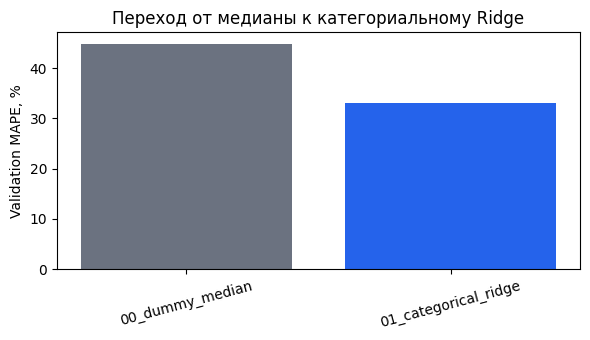

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
step_plot = progress.copy()
ax.bar(step_plot["model_step"], step_plot["valid_mape_pct"], color=["#6b7280", "#2563eb"])
ax.set_title("Переход от медианы к категориальному Ridge")
ax.set_ylabel("Validation MAPE, %")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### Вывод по категориальным признакам

Категориальные признаки снижают validation MAPE с `44.86%` до `33.09%`. Основной прирост связан с профессиональной ролью, опытом, графиком работы и географией вакансии.

## 5. Компактный TF-IDF

Следующий этап использует короткие текстовые поля: название вакансии, роль, навыки, работодателя и отрасль. Для текста строятся word n-grams, затем они объединяются со структурированными признаками.

In [7]:
COMPACT_TEXT_COLUMNS = [
    "name",
    "name_clean",
    "professional_roles_name",
    "key_skills_name",
    "employer_name",
    "employer_industries",
    "employer_id_token",
]


def join_text_columns(df: pd.DataFrame) -> pd.Series:
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    data = df.copy()
    for column in data.columns:
        data[column] = data[column].fillna("").astype(str)
    return data.agg(" ".join, axis=1).str.replace(r"\s+", " ", regex=True).str.strip()


def make_tfidf_ridge(
    text_columns: list[str],
    word_features: int,
    char_features: int | None = None,
    alpha: float = 12.0,
    log_target: bool = False,
    min_df: int = 2,
):
    text_transformers = [
        (
            "word_tfidf",
            TfidfVectorizer(
                max_features=word_features,
                ngram_range=(1, 2),
                min_df=min_df,
                sublinear_tf=True,
                strip_accents="unicode",
            ),
        )
    ]
    if char_features:
        text_transformers.append(
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    max_features=char_features,
                    ngram_range=(3, 5),
                    min_df=min_df,
                    sublinear_tf=True,
                    strip_accents="unicode",
                ),
            )
        )

    text_pipe = Pipeline([
        ("join", FunctionTransformer(join_text_columns, validate=False)),
        ("tfidf", FeatureUnion(text_transformers)),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_pipe, text_columns),
            ("cat", categorical_pipe, CATEGORICAL_COLUMNS),
            ("num", numeric_pipe, NUMERIC_META_COLUMNS),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )

    base = Pipeline([
        ("prep", preprocess),
        ("model", Ridge(alpha=alpha)),
    ])

    if not log_target:
        return base

    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


compact_tfidf_model = make_tfidf_ridge(
    COMPACT_TEXT_COLUMNS,
    word_features=30000,
    char_features=None,
    alpha=12.0,
    log_target=False,
)
fitted_compact, compact_result = evaluate_model(
    "02_compact_tfidf_ridge",
    compact_tfidf_model,
    X_train,
    y_train,
)

compact_submission = save_submission(fitted_compact, X_test, SUBMISSION_02_PATH)

progress = pd.DataFrame([dummy_result, structured_result, compact_result])
display(progress.round(5))

,model_step,input_columns,train_mape,valid_mape,valid_mape_pct,fit_eval_seconds
0,00_dummy_median,1,0.45020,0.44857,44.85748,0.00280
1,01_categorical_ridge,33,0.32351,0.33091,33.09072,1.17565
2,02_compact_tfidf_ridge,33,0.27023,0.29022,29.02205,13.29706


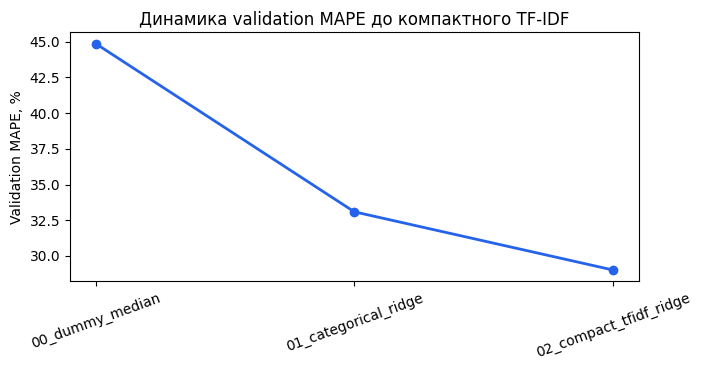

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.8))
step_plot = progress.copy()
ax.plot(step_plot["model_step"], step_plot["valid_mape_pct"], marker="o", linewidth=2, color="#2563eb")
ax.set_title("Динамика validation MAPE до компактного TF-IDF")
ax.set_ylabel("Validation MAPE, %")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Вывод по компактному TF-IDF

Короткие текстовые поля снижают validation MAPE до `29.02%`. Название вакансии, навыки, работодатель и профессиональная роль добавляют информацию, которой недостаточно в категориальных признаках.

## 6. Расширенный TF-IDF и лог-трансформация

Финальная конфигурация добавляет лемматизированные описания вакансий и символьные n-grams. Целевая переменная преобразуется через `log1p`, что согласуется с правым хвостом распределения зарплаты.

In [9]:
DESCRIPTION_TEXT_COLUMNS = [
    "name",
    "name_clean",
    "employer_name",
    "professional_roles_name",
    "key_skills_name",
    "employer_industries",
    "unified_address_city",
    "unified_address_state",
    "unified_address_region",
    "lemmaized_wo_stopwords_raw_description",
    "lemmaized_wo_stopwords_raw_branded_description",
    "employer_id_token",
]

description_tfidf_model = make_tfidf_ridge(
    DESCRIPTION_TEXT_COLUMNS,
    word_features=30000,
    char_features=10000,
    alpha=12.0,
    log_target=True,
    min_df=3,
)
fitted_description, description_result = evaluate_model(
    "03_description_tfidf_log_target",
    description_tfidf_model,
    X_train,
    y_train,
)

final_submission = save_submission(fitted_description, X_test, FINAL_SUBMISSION_PATH)
progress = pd.DataFrame([dummy_result, structured_result, compact_result, description_result])
display(progress.round(5))
display(final_submission.head())

,model_step,input_columns,train_mape,valid_mape,valid_mape_pct,fit_eval_seconds
0,00_dummy_median,1,0.45020,0.44857,44.85748,0.00280
1,01_categorical_ridge,33,0.32351,0.33091,33.09072,1.17565
2,02_compact_tfidf_ridge,33,0.27023,0.29022,29.02205,13.29706
3,03_description_tfidf_log_target,33,0.21798,0.23828,23.82806,502.45132


,id,salary_mean_net
0,46224201,114628.85593
1,42119402,51063.72941
2,45716401,27497.30876
3,43716203,22439.23715
4,47109602,47033.08673


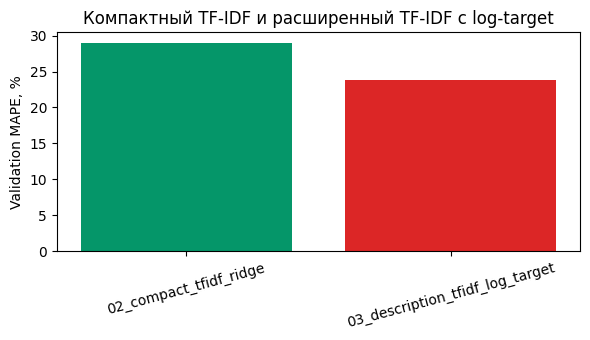

In [10]:
target_transform_comparison = pd.DataFrame([compact_result, description_result])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(
    target_transform_comparison["model_step"],
    target_transform_comparison["valid_mape_pct"],
    color=["#059669", "#dc2626"],
)
ax.set_title("Компактный TF-IDF и расширенный TF-IDF с log-target")
ax.set_ylabel("Validation MAPE, %")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### Вывод по расширенному TF-IDF

Расширенный TF-IDF по описаниям и лог-трансформация целевой переменной дают лучший результат: validation MAPE `23.83%`. Улучшение относительно компактного TF-IDF показывает, что длинные описания содержат существенный зарплатный сигнал.

## 7. Сравнение этапов

,model_step,input_columns,train_mape,valid_mape,valid_mape_pct,fit_eval_seconds
0,03_description_tfidf_log_target,33,0.21798,0.23828,23.82806,502.45132
1,02_compact_tfidf_ridge,33,0.27023,0.29022,29.02205,13.29706
2,01_categorical_ridge,33,0.32351,0.33091,33.09072,1.17565
3,00_dummy_median,1,0.45020,0.44857,44.85748,0.00280


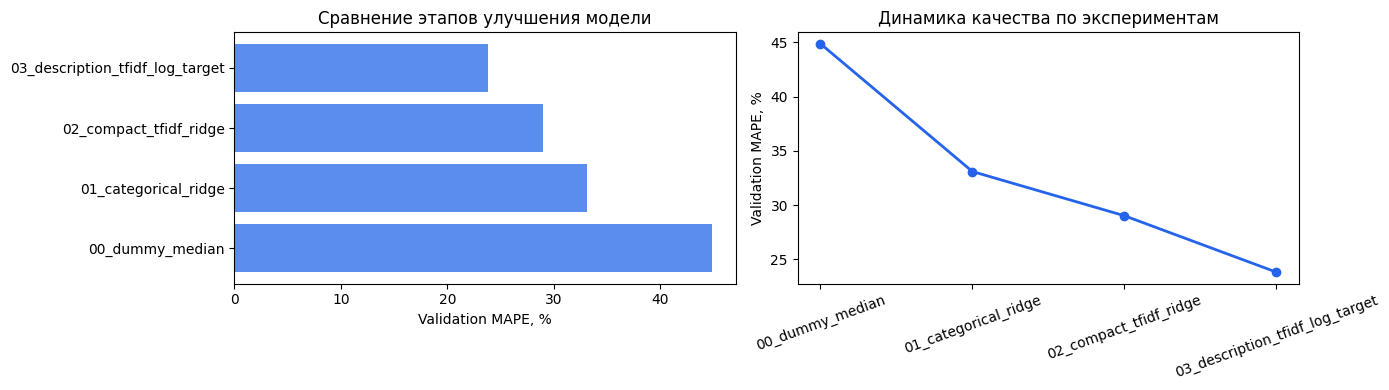

In [11]:
final_comparison = pd.DataFrame([dummy_result, structured_result, compact_result, description_result])
final_comparison = final_comparison.sort_values("valid_mape").reset_index(drop=True)

display(final_comparison.round(5))

plot_data = final_comparison.sort_values("valid_mape", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(plot_data["model_step"], plot_data["valid_mape_pct"], color="#5B8DEF")
axes[0].set_xlabel("Validation MAPE, %")
axes[0].set_title("Сравнение этапов улучшения модели")

line_data = pd.DataFrame([dummy_result, structured_result, compact_result, description_result])
axes[1].plot(line_data["model_step"], line_data["valid_mape_pct"], marker="o", linewidth=2, color="#2563eb")
axes[1].set_ylabel("Validation MAPE, %")
axes[1].set_title("Динамика качества по экспериментам")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()

## Промежуточный анализ финальной модели
Для финальной конфигурации используется validation-прогноз: каждая строка из validation-части предсказывается моделью, которая не обучалась на этой строке. Это позволяет оценить структуру ошибок без опоры на train-метрику.

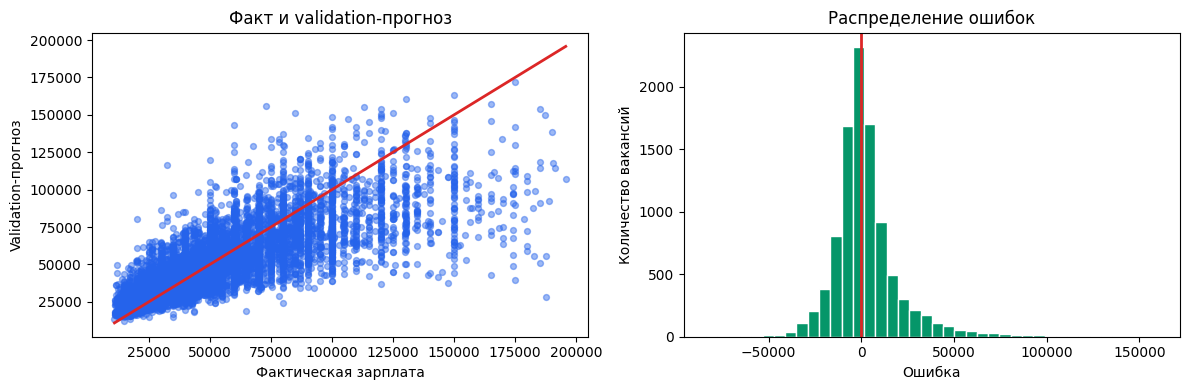

,residual,absolute_percentage_error
count,9811.00000,9811.00000
mean,2254.41760,0.23830
std,18196.38260,0.23230
min,-83727.52150,0.00010
25%,-7059.19020,0.08210
50%,-368.49570,0.17760
75%,7953.54460,0.32340
max,159713.11620,3.16250


In [12]:
final_artifacts = evaluation_artifacts["03_description_tfidf_log_target"]
final_valid_y = final_artifacts["valid_y"]
final_valid_pred = final_artifacts["valid_pred"]
final_residuals = final_artifacts["valid_residuals"]
final_ape = np.abs(final_residuals) / final_valid_y.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(final_valid_y, final_valid_pred, alpha=0.45, s=18, color="#2563eb")
lims = [
    min(final_valid_y.min(), final_valid_pred.min()),
    max(final_valid_y.max(), final_valid_pred.max()),
]
axes[0].plot(lims, lims, color="#dc2626", linewidth=2)
axes[0].set_title("Факт и validation-прогноз")
axes[0].set_xlabel("Фактическая зарплата")
axes[0].set_ylabel("Validation-прогноз")

axes[1].hist(final_residuals, bins=40, color="#059669", edgecolor="white")
axes[1].axvline(0, color="#dc2626", linewidth=2)
axes[1].set_title("Распределение ошибок")
axes[1].set_xlabel("Ошибка")
axes[1].set_ylabel("Количество вакансий")

plt.tight_layout()
plt.show()

error_summary = pd.Series(final_residuals, name="residual").describe().to_frame()
error_summary["absolute_percentage_error"] = pd.Series(final_ape).describe().values
display(error_summary.round(4))

Ошибки финальной модели сосредоточены около нуля, но разброс увеличивается на высоких зарплатах. Это ожидаемо для задачи с правым хвостом целевой переменной: редкие дорогие вакансии сложнее предсказывать по текстовому описанию и категориальным признакам.

## 8. Вывод

1. Медианная модель задает контрольный уровень: validation MAPE `44.86%`.
2. Категориальный Ridge снижает validation MAPE до `33.09%`; основными признаками становятся роль, опыт, график и регион.
3. Компактный TF-IDF снижает validation MAPE до `29.02%`, добавляя сигнал из названия, навыков и работодателя.
4. Расширенный TF-IDF по описаниям и `log1p`-трансформация целевой переменной дают лучший результат: validation MAPE `23.83%`.
5. Анализ validation-ошибок показывает отсутствие выраженного систематического смещения, но верхний хвост зарплат остается наиболее сложной областью.
6. Финальная версия сохраняет файл  `submissions/submission_03_description_tfidf.csv`.
